In [1]:
import pandas as pd

df = pd.read_csv("emi_prediction_dataset.csv")



C:\Users\HP\AppData\Local\Temp\ipykernel_10320\4113991267.py:3: DtypeWarning: Columns (0) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("emi_prediction_dataset.csv")


In [2]:
df


,age,gender,marital_status,education,monthly_salary,employment_type,years_of_employment,company_type,house_type,monthly_rent,...,existing_loans,current_emi_amount,credit_score,bank_balance,emergency_fund,emi_scenario,requested_amount,requested_tenure,emi_eligibility,max_monthly_emi
0,38.0,Female,Married,Professional,82600.0,Private,0.9,Mid-size,Rented,20000.0,...,Yes,23700.0,660.0,303200.0,70200.0,Personal Loan EMI,850000.0,15,Not_Eligible,500.0
1,38.0,Female,Married,Graduate,21500.0,Private,7.0,MNC,Family,0.0,...,Yes,4100.0,714.0,92500.0,26900.0,E-commerce Shopping EMI,128000.0,19,Not_Eligible,700.0
2,38.0,Male,Married,Professional,86100.0,Private,5.8,Startup,Own,0.0,...,No,0.0,650.0,672100.0,324200.0,Education EMI,306000.0,16,Eligible,27775.0
3,58.0,Female,Married,High School,66800.0,Private,2.2,Mid-size,Own,0.0,...,No,0.0,685.0,440900.0,178100.0,Vehicle EMI,304000.0,83,Eligible,16170.0
4,48.0,Female,Married,Professional,57300.0,Private,3.4,Mid-size,Family,0.0,...,No,0.0,770.0,97300.0,28200.0,Home Appliances EMI,252000.0,7,Not_Eligible,500.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
404795,27.0,Male,Married,Graduate,32400.0,Private,5.0,Large Indian,Rented,10400.0,...,No,0.0,649.0,62000.0,32600.0,Personal Loan EMI,506000.0,47,Not_Eligible,500.0
404796,38.0,Male,Married,Post Graduate,49200.0,Private,1.9,MNC,Own,0.0,...,No,0.0,712.0,142200.0,38100.0,Personal Loan EMI,708000.0,33,Not_Eligible,5200.0
404797,32.0,Male,Single,Graduate,25700.0,Private,3.2,MNC,Rented,6300.0,...,No,0.0,676.0,191600.0,39700.0,Home Appliances EMI,93000.0,21,High_Risk,5665.0
404798,48.0,Male,Married,Graduate,47200.0,Private,3.0,MNC,Own,0.0,...,No,0.0,784.0,170400.0,45600.0,Home Appliances EMI,144000.0,36,Eligible,14460.0


In [3]:
df.columns


Index(['age', 'gender', 'marital_status', 'education', 'monthly_salary',
       'employment_type', 'years_of_employment', 'company_type', 'house_type',
       'monthly_rent', 'family_size', 'dependents', 'school_fees',
       'college_fees', 'travel_expenses', 'groceries_utilities',
       'other_monthly_expenses', 'existing_loans', 'current_emi_amount',
       'credit_score', 'bank_balance', 'emergency_fund', 'emi_scenario',
       'requested_amount', 'requested_tenure', 'emi_eligibility',
       'max_monthly_emi'],
      dtype='object')

In [4]:
import pandas as pd
import numpy as np
print(df.shape)
print(df.head())
print(df.info())

(404800, 27)
    age  gender marital_status     education monthly_salary employment_type  \
0  38.0  Female        Married  Professional        82600.0         Private   
1  38.0  Female        Married      Graduate        21500.0         Private   
2  38.0    Male        Married  Professional        86100.0         Private   
3  58.0  Female        Married   High School        66800.0         Private   
4  48.0  Female        Married  Professional        57300.0         Private   

   years_of_employment company_type house_type  monthly_rent  ...  \
0                  0.9     Mid-size     Rented       20000.0  ...   
1                  7.0          MNC     Family           0.0  ...   
2                  5.8      Startup        Own           0.0  ...   
3                  2.2     Mid-size        Own           0.0  ...   
4                  3.4     Mid-size     Family           0.0  ...   

   existing_loans  current_emi_amount  credit_score  bank_balance  \
0             Yes           

In [9]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder


# 🔹 Remove duplicate columns
df = df.loc[:, ~df.columns.duplicated()]

# 🔹 Reduce memory
for col in df.select_dtypes(include=['int64']).columns:
    df[col] = df[col].astype('int32')

for col in df.select_dtypes(include=['float64']).columns:
    df[col] = df[col].astype('float32')

# 🔹 Handle missing values
for col in df.columns:
    if df[col].dtype.kind in 'biufc':   # numeric
        df[col].fillna(df[col].median(), inplace=True)
    else:
        df[col].fillna(df[col].mode()[0], inplace=True)

# 🔹 Encode categorical (FIXED)
le = LabelEncoder()
for col in df.select_dtypes(include='object').columns:
    df[col] = df[col].astype(str)   # ⭐ IMPORTANT FIX
    df[col] = le.fit_transform(df[col])

# 🔹 Remove duplicates
df = df.drop_duplicates()

# 🔹 Final check
print("Missing values:\n", df.isnull().sum())
print("Shape:", df.shape)

Missing values:
 age                       0
gender                    0
marital_status            0
education                 0
monthly_salary            0
employment_type           0
years_of_employment       0
company_type              0
house_type                0
monthly_rent              0
family_size               0
dependents                0
school_fees               0
college_fees              0
travel_expenses           0
groceries_utilities       0
other_monthly_expenses    0
existing_loans            0
current_emi_amount        0
credit_score              0
bank_balance              0
emergency_fund            0
emi_scenario              0
requested_amount          0
requested_tenure          0
emi_eligibility           0
max_monthly_emi           0
dtype: int64
Shape: (404800, 27)


In [10]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 404800 entries, 0 to 404799
Data columns (total 27 columns):
 #   Column                  Non-Null Count   Dtype  
---  ------                  --------------   -----  
 0   age                     404800 non-null  int64  
 1   gender                  404800 non-null  int64  
 2   marital_status          404800 non-null  int64  
 3   education               404800 non-null  int64  
 4   monthly_salary          404800 non-null  int64  
 5   employment_type         404800 non-null  int64  
 6   years_of_employment     404800 non-null  float32
 7   company_type            404800 non-null  int64  
 8   house_type              404800 non-null  int64  
 9   monthly_rent            404800 non-null  float32
 10  family_size             404800 non-null  int32  
 11  dependents              404800 non-null  int32  
 12  school_fees             404800 non-null  float32
 13  college_fees            404800 non-null  float32
 14  travel_expenses     

,age,gender,marital_status,education,monthly_salary,employment_type,years_of_employment,company_type,house_type,monthly_rent,...,existing_loans,current_emi_amount,credit_score,bank_balance,emergency_fund,emi_scenario,requested_amount,requested_tenure,emi_eligibility,max_monthly_emi
count,404800.000000,404800.000000,404800.000000,404800.000000,404800.000000,404800.000000,404800.000000,404800.000000,404800.000000,404800.000000,...,404800.000000,404800.000000,404800.000000,404800.000000,404800.000000,404800.000000,4.048000e+05,404800.000000,404800.000000,404800.000000
mean,14.784004,3.798626,0.239533,1.092799,7244.123854,0.899622,5.364079,1.500914,1.149973,5793.516602,...,0.399143,4543.407227,700.857056,4690.578142,96636.812500,2.000064,3.708554e+05,29.126677,1.588992,6763.602051
std,7.968606,1.496421,0.426799,1.135125,3788.792842,0.539045,6.079134,1.359534,0.791177,8634.375977,...,0.489723,7034.901367,88.170807,3006.853976,81154.851562,1.414112,3.451945e+05,18.100854,0.780953,7741.263184
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.500000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,1400.000000,0.000000,1.000000e+04,3.000000,0.000000,500.000000
25%,9.000000,2.000000,0.000000,0.000000,3468.000000,1.000000,1.200000,0.000000,1.000000,0.000000,...,0.000000,0.000000,654.000000,2310.000000,38600.000000,1.000000,1.240000e+05,15.000000,2.000000,500.000000
50%,16.000000,5.000000,0.000000,1.000000,7684.000000,1.000000,3.200000,1.000000,1.000000,0.000000,...,0.000000,0.000000,701.000000,3978.000000,74000.000000,2.000000,2.360000e+05,25.000000,2.000000,4211.200195
75%,23.000000,5.000000,0.000000,2.000000,10482.000000,1.000000,7.200000,2.000000,2.000000,10600.000000,...,1.000000,8000.000000,748.000000,6537.000000,130200.000000,3.000000,4.940000e+05,40.000000,2.000000,9792.000000
max,32.000000,7.000000,1.000000,3.000000,13661.000000,2.000000,36.000000,4.000000,2.000000,80000.000000,...,1.000000,56300.000000,1200.000000,12260.000000,891500.000000,4.000000,1.500000e+06,84.000000,2.000000,91040.398438


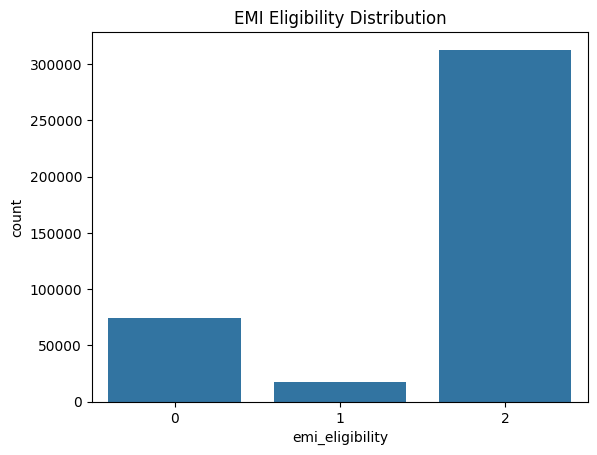

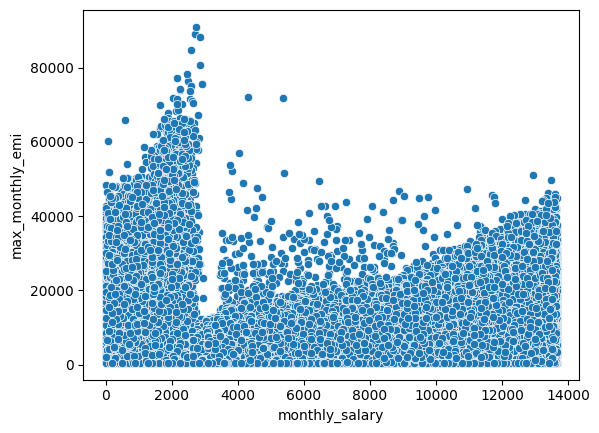

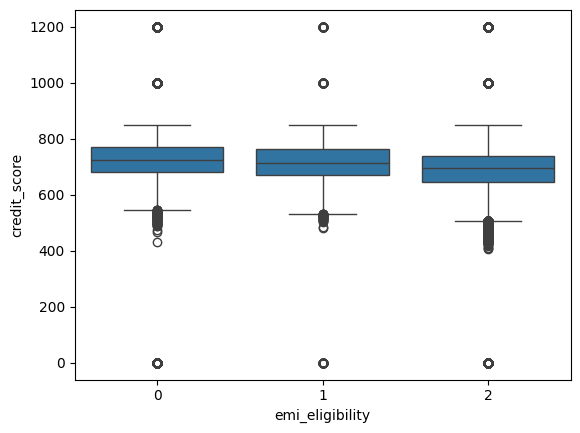

In [11]:
import seaborn as sns
import matplotlib.pyplot as plt

# Target distribution
sns.countplot(x='emi_eligibility', data=df)
plt.title("EMI Eligibility Distribution")
plt.show()

# Salary vs EMI
sns.scatterplot(x='monthly_salary', y='max_monthly_emi', data=df)
plt.show()

# Credit score vs eligibility
sns.boxplot(x='emi_eligibility', y='credit_score', data=df)
plt.show()

In [12]:
df.dtypes

age                         int64
gender                      int64
marital_status              int64
education                   int64
monthly_salary              int64
employment_type             int64
years_of_employment       float32
company_type                int64
house_type                  int64
monthly_rent              float32
family_size                 int32
dependents                  int32
school_fees               float32
college_fees              float32
travel_expenses           float32
groceries_utilities       float32
other_monthly_expenses    float32
existing_loans              int64
current_emi_amount        float32
credit_score              float32
bank_balance                int64
emergency_fund            float32
emi_scenario                int64
requested_amount          float32
requested_tenure            int32
emi_eligibility             int64
max_monthly_emi           float32
dtype: object

In [13]:
df['monthly_salary'] = pd.to_numeric(df['monthly_salary'], errors='coerce')
df['current_emi_amount'] = pd.to_numeric(df['current_emi_amount'], errors='coerce')

In [14]:
df.isnull().sum()

age                       0
gender                    0
marital_status            0
education                 0
monthly_salary            0
employment_type           0
years_of_employment       0
company_type              0
house_type                0
monthly_rent              0
family_size               0
dependents                0
school_fees               0
college_fees              0
travel_expenses           0
groceries_utilities       0
other_monthly_expenses    0
existing_loans            0
current_emi_amount        0
credit_score              0
bank_balance              0
emergency_fund            0
emi_scenario              0
requested_amount          0
requested_tenure          0
emi_eligibility           0
max_monthly_emi           0
dtype: int64

In [15]:
df.fillna(0, inplace=True)

In [16]:
cols = [
    'monthly_salary',
    'current_emi_amount',
    'bank_balance',
    'monthly_rent',
    'school_fees',
    'college_fees',
    'travel_expenses',
    'groceries_utilities',
    'other_monthly_expenses',
    'requested_amount'
]

for col in cols:
    df[col] = pd.to_numeric(df[col], errors='coerce')

In [17]:
df.fillna(0, inplace=True)

In [18]:
# Financial ratios
df['debt_to_income'] = df['current_emi_amount'] / df['monthly_salary']

df['total_expenses'] = (
    df['monthly_rent'] + df['school_fees'] + df['college_fees'] +
    df['travel_expenses'] + df['groceries_utilities'] +
    df['other_monthly_expenses']
)

df['expense_to_income'] = df['total_expenses'] / df['monthly_salary']
df['savings_ratio'] = df['bank_balance'] / df['monthly_salary']


df['emi_to_income_ratio'] = df['current_emi_amount'] / df['monthly_salary']


In [19]:
df.columns

Index(['age', 'gender', 'marital_status', 'education', 'monthly_salary',
       'employment_type', 'years_of_employment', 'company_type', 'house_type',
       'monthly_rent', 'family_size', 'dependents', 'school_fees',
       'college_fees', 'travel_expenses', 'groceries_utilities',
       'other_monthly_expenses', 'existing_loans', 'current_emi_amount',
       'credit_score', 'bank_balance', 'emergency_fund', 'emi_scenario',
       'requested_amount', 'requested_tenure', 'emi_eligibility',
       'max_monthly_emi', 'debt_to_income', 'total_expenses',
       'expense_to_income', 'savings_ratio', 'emi_to_income_ratio'],
      dtype='object')

In [20]:
# Encoding
from sklearn.preprocessing import LabelEncoder

cat_cols = [
    'gender', 'marital_status', 'education', 'employment_type',
    'company_type', 'house_type', 'existing_loans', 'emi_scenario',
    'emi_eligibility'
]

le = LabelEncoder()

for col in cat_cols:
    df[col] = le.fit_transform(df[col])

In [21]:
# check missing value
print(df.isnull().sum())
df.fillna(0, inplace=True)

age                       0
gender                    0
marital_status            0
education                 0
monthly_salary            0
employment_type           0
years_of_employment       0
company_type              0
house_type                0
monthly_rent              0
family_size               0
dependents                0
school_fees               0
college_fees              0
travel_expenses           0
groceries_utilities       0
other_monthly_expenses    0
existing_loans            0
current_emi_amount        0
credit_score              0
bank_balance              0
emergency_fund            0
emi_scenario              0
requested_amount          0
requested_tenure          0
emi_eligibility           0
max_monthly_emi           0
debt_to_income            0
total_expenses            0
expense_to_income         0
savings_ratio             0
emi_to_income_ratio       0
dtype: int64


In [22]:
X = df.drop(['emi_eligibility', 'max_monthly_emi'], axis=1)

y_class = df['emi_eligibility']

In [23]:
X = X.select_dtypes(include=['int64', 'float64'])
print(df.dtypes)

age                         int64
gender                      int64
marital_status              int64
education                   int64
monthly_salary              int64
employment_type             int64
years_of_employment       float32
company_type                int64
house_type                  int64
monthly_rent              float32
family_size                 int32
dependents                  int32
school_fees               float32
college_fees              float32
travel_expenses           float32
groceries_utilities       float32
other_monthly_expenses    float32
existing_loans              int64
current_emi_amount        float32
credit_score              float32
bank_balance                int64
emergency_fund            float32
emi_scenario                int64
requested_amount          float32
requested_tenure            int32
emi_eligibility             int64
max_monthly_emi           float32
debt_to_income            float64
total_expenses            float32
expense_to_inc

In [24]:
from sklearn.model_selection import train_test_split

# Step 1: Define features
features = [
'age', 'gender', 'marital_status', 'education', 'monthly_salary',
'employment_type', 'years_of_employment', 'company_type', 'house_type',
'monthly_rent', 'family_size', 'dependents', 'school_fees',
'college_fees', 'travel_expenses', 'groceries_utilities',
'other_monthly_expenses', 'existing_loans', 'current_emi_amount',
'credit_score', 'bank_balance', 'emergency_fund', 'emi_scenario',
'requested_amount', 'requested_tenure', 'debt_to_income',
'total_expenses', 'expense_to_income', 'savings_ratio',
'emi_to_income_ratio'
]

# Step 2: Define X and y
X = df[features]
y_class = df['emi_eligibility']

# Step 3: Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y_class, test_size=0.2, random_state=42
)

In [ ]:
# Convert ALL categorical columns automatically
X = pd.get_dummies(df[features], drop_first=True)

y_class = df['emi_eligibility']

In [25]:
# regression
y_reg = df['max_monthly_emi']

X_train_r, X_test_r, y_train_r, y_test_r = train_test_split(
    X, y_reg, test_size=0.2, random_state=42
)

In [26]:
import pandas as pd
import numpy as np

# Step 1: Define features
features = [
'age', 'gender', 'marital_status', 'education', 'monthly_salary',
'employment_type', 'years_of_employment', 'company_type', 'house_type',
'monthly_rent', 'family_size', 'dependents', 'school_fees',
'college_fees', 'travel_expenses', 'groceries_utilities',
'other_monthly_expenses', 'existing_loans', 'current_emi_amount',
'credit_score', 'bank_balance', 'emergency_fund', 'emi_scenario',
'requested_amount', 'requested_tenure', 'debt_to_income',
'total_expenses', 'expense_to_income', 'savings_ratio',
'emi_to_income_ratio'
]

# Step 2: Create X safely
X = df[features].copy()

# Convert EVERYTHING to numeric
X = X.apply(pd.to_numeric, errors='coerce')

# Replace inf values
X.replace([np.inf, -np.inf], np.nan, inplace=True)

# Fill missing values
X.fillna(0, inplace=True)

# Step 3: Fix target
y = df['emi_eligibility']

from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
y = le.fit_transform(y)

# Step 4: Final safety check
print("Any object columns:", X.select_dtypes(include='object').columns)
print("Any nulls:", X.isnull().sum().sum())
print("Shape:", X.shape, y.shape)

# Step 5: Train-test split
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Step 6: Model training
from sklearn.ensemble import RandomForestClassifier
model = RandomForestClassifier(random_state=42)

model.fit(X_train, y_train)

print("✅ SUCCESS: Model trained")

Any object columns: Index([], dtype='object')
Any nulls: 0
Shape: (404800, 30) (404800,)
✅ SUCCESS: Model trained


In [27]:
pip install mlflow

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [ ]:
!pip install xgboost

   ---------------------------------------- 0.0/101.7 MB ? eta -:--:--
   ---------------------------------------- 0.3/101.7 MB ? eta -:--:--
   - -------------------------------------- 3.7/101.7 MB 18.4 MB/s eta 0:00:06
   - -------------------------------------- 5.0/101.7 MB 11.5 MB/s eta 0:00:09
   -- ------------------------------------- 6.0/101.7 MB 9.2 MB/s eta 0:00:11
   -- ------------------------------------- 7.1/101.7 MB 8.1 MB/s eta 0:00:12
   --- ------------------------------------ 8.1/101.7 MB 7.6 MB/s eta 0:00:13
   --- ------------------------------------ 8.7/101.7 MB 6.9 MB/s eta 0:00:14
   --- ------------------------------------ 8.7/101.7 MB 6.9 MB/s eta 0:00:14
   --- ------------------------------------ 8.9/101.7 MB 5.3 MB/s eta 0:00:18
   --- ------------------------------------ 9.2/101.7 MB 4.8 MB/s eta 0:00:20
   --- ------------------------------------ 9.7/101.7 MB 4.4 MB/s eta 0:00:22
   ---- ----------------------------------- 10.2/101.7 MB 4.2 MB/s eta 0:00:


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [28]:
import mlflow
import mlflow.sklearn
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

mlflow.set_experiment("EMI Risk Prediction")

with mlflow.start_run():
    model = RandomForestClassifier(n_estimators=100)
    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)
    accuracy = accuracy_score(y_test, y_pred)

    mlflow.log_param("n_estimators", 100)
    mlflow.log_metric("accuracy", accuracy)

    mlflow.sklearn.log_model(model, name="model")

2026/04/01 14:23:12 WARNING mlflow.utils.git_utils: Failed to import Git (the Git executable is probably not on your PATH), so Git SHA is not available. Error: Failed to initialize: Bad git executable.
The git executable must be specified in one of the following ways:
    - be included in your $PATH
    - be set via $GIT_PYTHON_GIT_EXECUTABLE
    - explicitly set via git.refresh(<full-path-to-git-executable>)

All git commands will error until this is rectified.

This initial message can be silenced or aggravated in the future by setting the
$GIT_PYTHON_REFRESH environment variable. Use one of the following values:
    - quiet|q|silence|s|silent|none|n|0: for no message or exception
    - warn|w|warning|log|l|1: for a warning message (logging level CRITICAL, displayed by default)
    - error|e|exception|raise|r|2: for a raised exception

Example:
    export GIT_PYTHON_REFRESH=quiet

2026/04/01 14:25:02 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle form

In [29]:
!mlflow ui


^C


In [31]:
import joblib
joblib.dump(model,"best_model.pkl")

['best_model.pkl']

In [32]:
!pip install streamlit


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [35]:
import joblib
joblib.dump(model,"best_model.pkl")

['best_model.pkl']

In [37]:
import streamlit as st
import joblib

model = joblib.load("best_model.pkl")

st.title("EMI Risk Assessment")

salary = st.number_input("Monthly Salary")
expenses = st.number_input("Monthly Expenses")

if st.button("Predict"):
    prediction = model.predict([[salary, expenses]])
    st.write("Result:", prediction)

2026-04-01 14:55:33.642 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-01 14:55:33.896 
  command:

    streamlit run C:\Users\HP\AppData\Roaming\Python\Python314\site-packages\ipykernel_launcher.py [ARGUMENTS]
2026-04-01 14:55:33.897 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-01 14:55:33.898 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-01 14:55:33.900 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-01 14:55:33.901 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-01 14:55:33.903 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-01 14:55:33.911 Thread 